# Business Objective

The objective of this analysis is to understand the structure of Flipkart's product catalog by exploring product categories, brands, pricing patterns, and product distribution.

The insights generated will help identify dominant categories, major brands, and pricing trends across the platform.

# 1. Libraries Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')

print("Libraries loaded successfully.")

# 2. Load Dataset
In this section we will explore the source dataset.

Let's read the data and look at the first 5 rows using the head method. The number of the output rows from the dataset is determined by the head method parameter.

In [ ]:
products = pd.read_csv(r"D:\Portfolio Projects\Flipkart-Sales-Analytics\data\products.csv")

products.head()

,Unnamed: 0,product_id,product_name,unit,product_type,brand_name,manufacturer_name,l0_category,l1_category,l2_category,l0_category_id,l1_category_id,l2_category_id
0,0,476763,Christmas - Card,1 unit,Card,NaN,HOT,Specials,Bill Breaker,Bill Breaker,343,1741,1741
1,1,483436,Plum BodyLovin' Hawaiian Rumba Shower Gel - Sa...,20 ml,Sample,Plum BodyLovin',Pureplay Skin Sciences India Pvt. Ltd.,Specials,Free Store,Free Store,343,1493,1493
2,2,476825,Diwali Gift Card Free - Sample,1 unit,Sample,NaN,HOT,Specials,Bill Breaker,Bill Breaker,343,1741,1741
3,3,483438,Plum BodyLovin' Trippin' Mimosas Shower Gel - ...,20 ml,Sample,Plum BodyLovin',Pureplay Skin Sciences India Pvt. Ltd.,Specials,Free Store,Free Store,343,1493,1493
4,4,480473,Flipkart Valentine Day Greeting - Card,1 unit,Card,Flipkart,Dummy Manufacturer,Specials,Bill Breaker,Bill Breaker,343,1741,1741


# 3. Dataset Overview

Let's look at the dataset size, feature names and their types

In [ ]:
# Drop unnamed index column
products.drop(columns=['Unnamed: 0'], inplace=True)

products.head()

,product_id,product_name,unit,product_type,brand_name,manufacturer_name,l0_category,l1_category,l2_category,l0_category_id,l1_category_id,l2_category_id
0,476763,Christmas - Card,1 unit,Card,NaN,HOT,Specials,Bill Breaker,Bill Breaker,343,1741,1741
1,483436,Plum BodyLovin' Hawaiian Rumba Shower Gel - Sa...,20 ml,Sample,Plum BodyLovin',Pureplay Skin Sciences India Pvt. Ltd.,Specials,Free Store,Free Store,343,1493,1493
2,476825,Diwali Gift Card Free - Sample,1 unit,Sample,NaN,HOT,Specials,Bill Breaker,Bill Breaker,343,1741,1741
3,483438,Plum BodyLovin' Trippin' Mimosas Shower Gel - ...,20 ml,Sample,Plum BodyLovin',Pureplay Skin Sciences India Pvt. Ltd.,Specials,Free Store,Free Store,343,1493,1493
4,480473,Flipkart Valentine Day Greeting - Card,1 unit,Card,Flipkart,Dummy Manufacturer,Specials,Bill Breaker,Bill Breaker,343,1741,1741


In [ ]:
#Shape
products.shape

(32226, 12)

In [ ]:
products.columns.tolist()

['product_id',
 'product_name',
 'unit',
 'product_type',
 'brand_name',
 'manufacturer_name',
 'l0_category',
 'l1_category',
 'l2_category',
 'l0_category_id',
 'l1_category_id',
 'l2_category_id']

In [ ]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32226 entries, 0 to 32225
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   product_id         32226 non-null  int64
 1   product_name       32226 non-null  str  
 2   unit               32226 non-null  str  
 3   product_type       32226 non-null  str  
 4   brand_name         30788 non-null  str  
 5   manufacturer_name  29810 non-null  str  
 6   l0_category        32226 non-null  str  
 7   l1_category        32226 non-null  str  
 8   l2_category        32226 non-null  str  
 9   l0_category_id     32226 non-null  int64
 10  l1_category_id     32226 non-null  int64
 11  l2_category_id     32226 non-null  int64
dtypes: int64(4), str(8)
memory usage: 3.0 MB


In [ ]:
products.describe(include=['number']).round(2)

,product_id,l0_category_id,l1_category_id,l2_category_id
count,32226.00,32226.00,32226.00,32226.00
mean,401505.64,602.08,912.25,819.40
std,147362.04,627.88,484.41,607.57
min,1.00,4.00,19.00,6.00
25%,396231.50,15.00,707.00,133.00
50%,477867.50,175.00,975.00,958.00
75%,489523.75,1379.00,1160.00,1177.00
max,498814.00,1557.00,2039.00,2039.00


In [ ]:
products.describe(include=['object'])

,product_name,unit,product_type,brand_name,manufacturer_name,l0_category,l1_category,l2_category
count,32226,32226,32226,30788,29810,32226,32226,32226
unique,28986,3160,2525,2192,1239,21,205,413
top,Stellar Home Multicolor Printed Double Bedshee...,1 unit,Combo,GHH,HOT,Home & Office,Kitchen & Dining Needs,Powdered Spices
freq,11,2299,700,582,2621,4734,1375,882


## Initial Observations

- The dataset contains 32,226 product records and 13 features.
- Product information includes product details, brand information, manufacturer details, and a three-level category hierarchy (L0, L1, and L2).
- The catalog consists of 21 top-level categories, 205 sub-categories, and 413 detailed categories.
- More than 2,000 brands are represented in the dataset, indicating a highly diverse product catalog.
- Further data cleaning and exploration will be performed to better understand the product portfolio and category structure.

# 4. Feature Understanding

| Feature | Description |
|----------|-------------|
| product_id | Unique identifier assigned to each product |
| product_name | Name of the product listed in the catalog |
| unit | Unit of measurement used for the product (e.g., piece, kg, litre) |
| product_type | Type or packaging classification of the product |
| brand_name | Brand associated with the product |
| manufacturer_name | Manufacturer or producer of the product |
| l0_category | Top-level product category |
| l1_category | Sub-category within the main category |
| l2_category | Detailed category within the sub-category |
| l0_category_id | Unique identifier for the L0 category |
| l1_category_id | Unique identifier for the L1 category |
| l2_category_id | Unique identifier for the L2 category |

### Category Hierarchy Example

**L0 Category → L1 Category → L2 Category**

Example:

**Home & Office → Kitchen & Dining Needs → Powdered Spices**

# 5. Data Cleaning

Data cleaning was performed to identify missing values and duplicate records that could affect the quality of the analysis.

In [ ]:
missing_df = pd.DataFrame({
    'Missing Count': products.isnull().sum(),
    'Missing %': (products.isnull().sum()/len(products)*100).round(2)
})

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
brand_name,1438,4.46
manufacturer_name,2416,7.50


In [ ]:
products.duplicated().sum()

np.int64(0)

### Observation

- `brand_name` contains 1,438 missing values (4.46%).
- `manufacturer_name` contains 2,416 missing values (7.50%).
- No duplicate records were found in the dataset.

## 6. Univariate Analysis

> Univariate analysis looks at **one column at a time** to understand its distribution,  
> frequency, and any dominant values.

### 6.1 Product Distribution by Top-Level Category (L0)

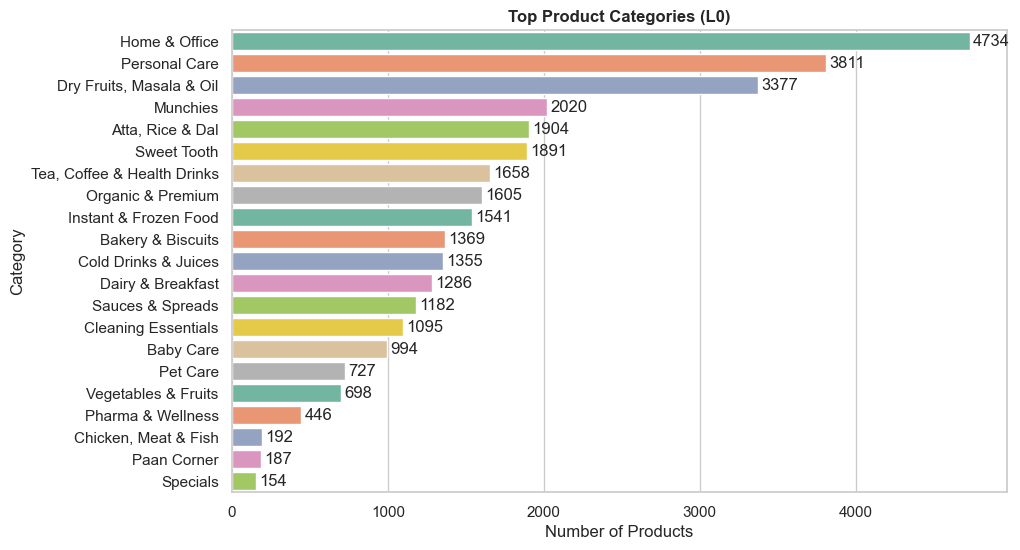

In [ ]:
l0_counts = products['l0_category'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=l0_counts.values, y=l0_counts.index,palette='Set2')

for i, v in enumerate(l0_counts.values): # i-> position , v->value
    ax.text(v + 20, i, str(v), va='center')
plt.title('Top Product Categories (L0)',fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

### Observation

- **Home & Office** and **Personal Care** are the two largest categories by product count.
- **Specials** and **Paan Corner** have the fewest listings.
- Category breadth spans FMCG, grocery, pharma, and household — reflecting a full quick-commerce catalog.

### 6.2 Top 15 Brands by Product Count

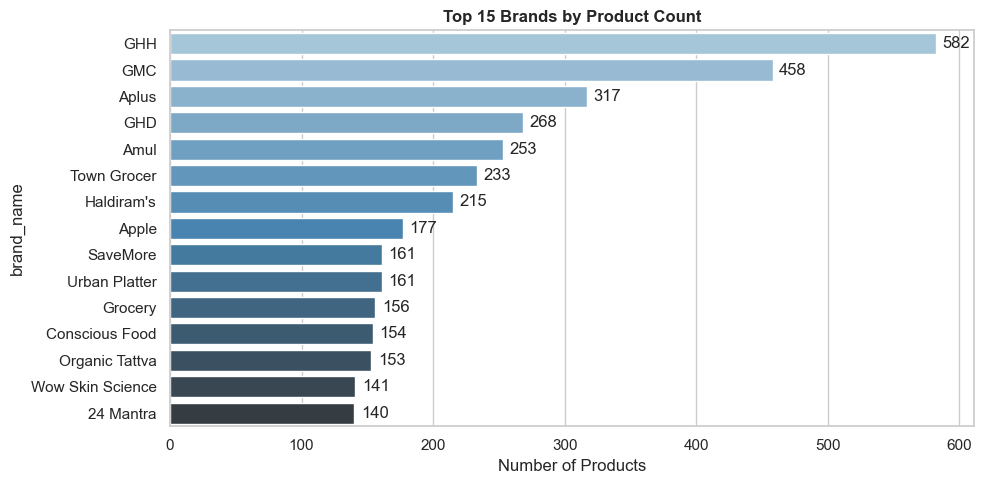

In [ ]:
top_brands = products['brand_name'].value_counts().head(15)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette='Blues_d'
)

for i, v in enumerate(top_brands.values):
    ax.text(v + 5, i, str(v), va='center')
plt.xlabel('Number of Products')
plt.title('Top 15 Brands by Product Count', fontweight='bold')
plt.tight_layout()
plt.show()

### Observation

- GHH has the highest number of products in the catalog.
- GMC and Aplus are the next most represented brands.
- A small number of brands contribute a significant share of products.
- The catalog remains diverse, containing products from over 2,000 brands.

### 6.3 Top 10 Manufacturers by Product Count

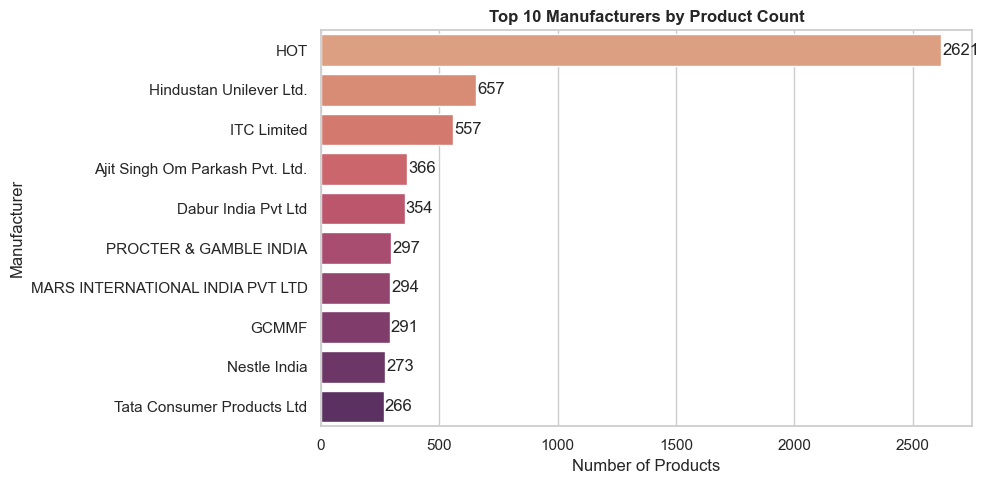

In [ ]:
top_manufacturers = products['manufacturer_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=top_manufacturers.values,
    y=top_manufacturers.index,
    palette='flare'
)

for i, v in enumerate(top_manufacturers.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title('Top 10 Manufacturers by Product Count', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Manufacturer')

plt.tight_layout()
plt.show()

### Observation

- HOT dominates the catalog with 2,621 products.
- Hindustan Unilever Ltd. and ITC Limited follow as major manufacturers.
- A few manufacturers account for a large share of products.
- The catalog is supported by a diverse set of suppliers beyond the top manufacturers.

### 6.4 Top 15 Product Types

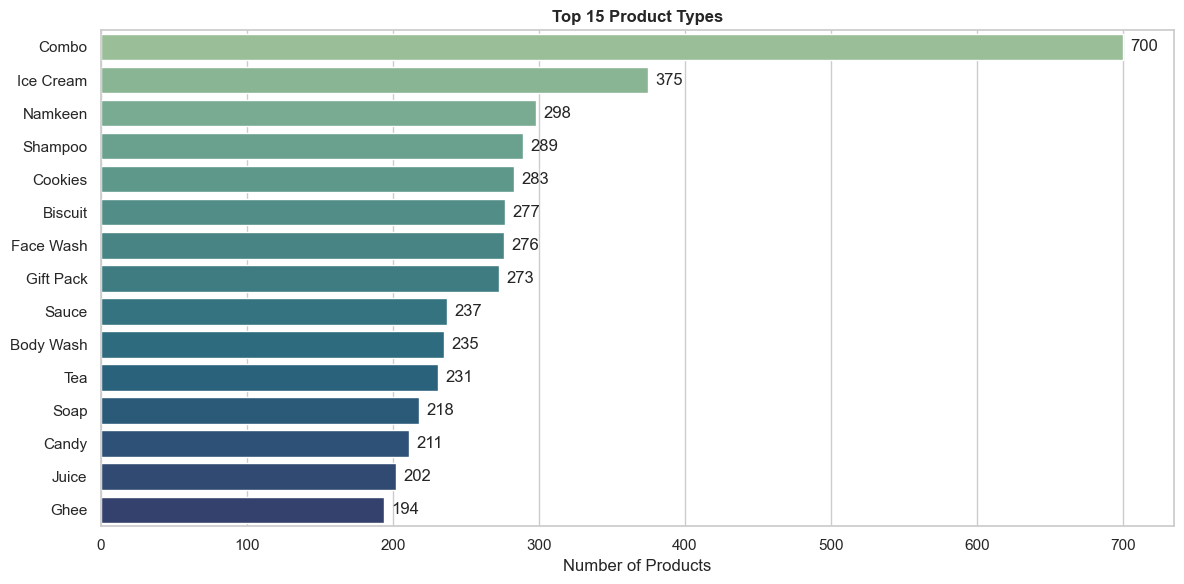

In [ ]:
top_types = products['product_type'].value_counts().head(15)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=top_types.values,
    y=top_types.index,
    palette='crest'
)

for i, v in enumerate(top_types.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title('Top 15 Product Types', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Observation

- **Combo** is the most common product type, indicating bundled product offerings.
- **Ice Cream, Namkeen, Shampoo, Cookies, Biscuits** are the most SKU-heavy categories.
- High presence of convenience and impulse-buy items aligns with quick-commerce demand patterns.

### 6.5 Top 15 Mid-Level Categories (L1)

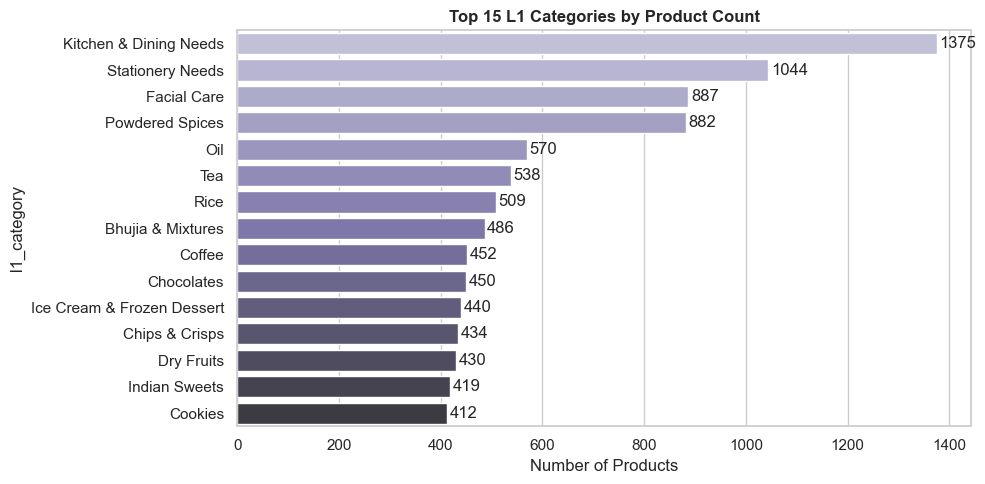

In [ ]:
top_l1 = products['l1_category'].value_counts().head(15)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=top_l1.values,
    y=top_l1.index,
    palette='Purples_d'
)

for i, v in enumerate(top_l1.values):
    ax.text(v + 5, i, str(v), va='center')
plt.xlabel('Number of Products')
plt.title('Top 15 L1 Categories by Product Count', fontweight='bold')
plt.tight_layout()
plt.show()

### Observation

- **Kitchen & Dining Needs** and **Stationery Needs** lead in mid-level category depth.
- **Facial Care, Powdered Spices, Oil, Tea, Rice** reflect core everyday demand.
- The catalog is heavily weighted towards kitchen, grocery, and personal care — typical of a grocery-first quick commerce platform.

# 7. Bivariate Analysis

### 7.1 Top Categories by Brand Diversity

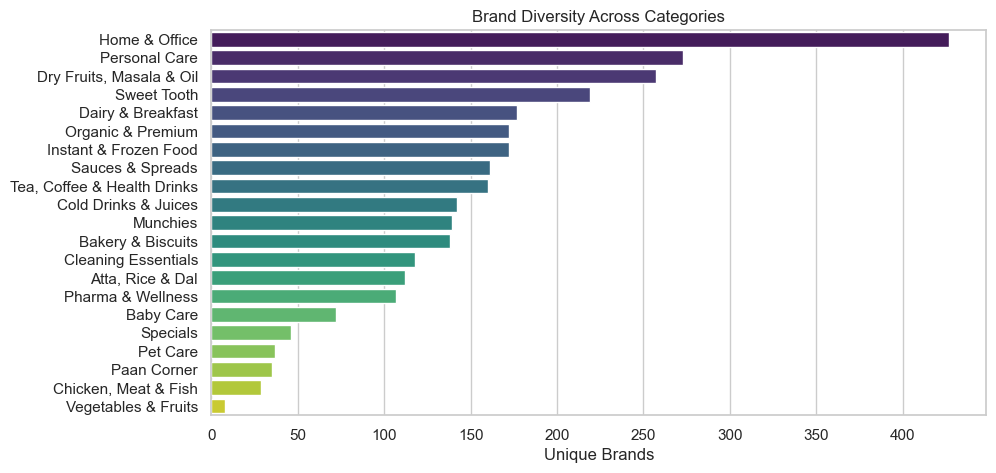

In [ ]:
brand_diversity = (
    products.groupby('l0_category')['brand_name']
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=brand_diversity.values,
    y=brand_diversity.index,
    palette='viridis'
)

plt.title('Brand Diversity Across Categories')
plt.xlabel('Unique Brands')
plt.ylabel('')
plt.show()

### Observation
- Some categories contain significantly more brands than others.
- Categories with high brand diversity indicate stronger competition.

### 7.2 Top Categories by Manufacturer Diversity

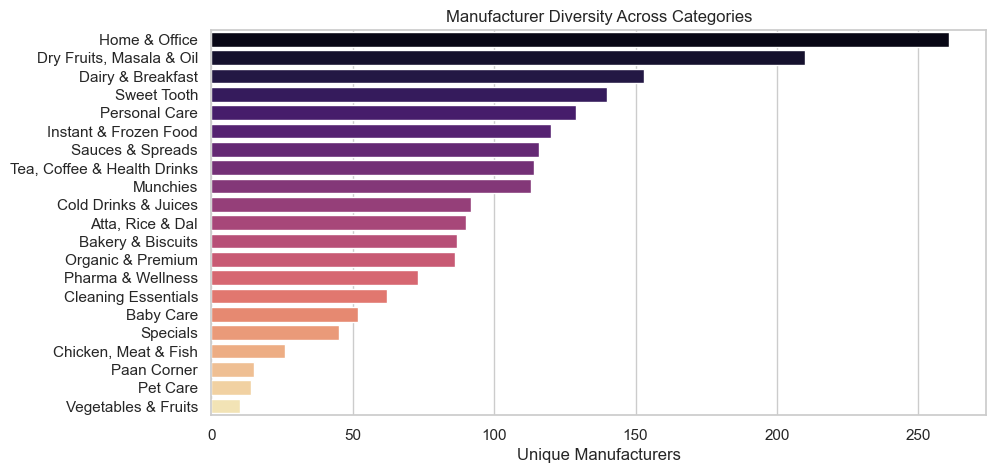

In [ ]:
manufacturer_diversity = (
    products.groupby('l0_category')['manufacturer_name']
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=manufacturer_diversity.values,
    y=manufacturer_diversity.index,
    palette='magma'
)

plt.title('Manufacturer Diversity Across Categories')
plt.xlabel('Unique Manufacturers')
plt.ylabel('')
plt.show()

### Observation 
- Categories with more manufacturers have a broader supplier base.
- Product supply is concentrated in a few categories.

---
# Business Questions

Based on the EDA above, here are the key business questions for the Products dataset.

---

## Q1. Which L0 Categories Have the Highest Product Variety?

Understanding which top-level categories contain the largest number of products helps identify 
where the product catalog is most extensive and where product assortment is concentrated.


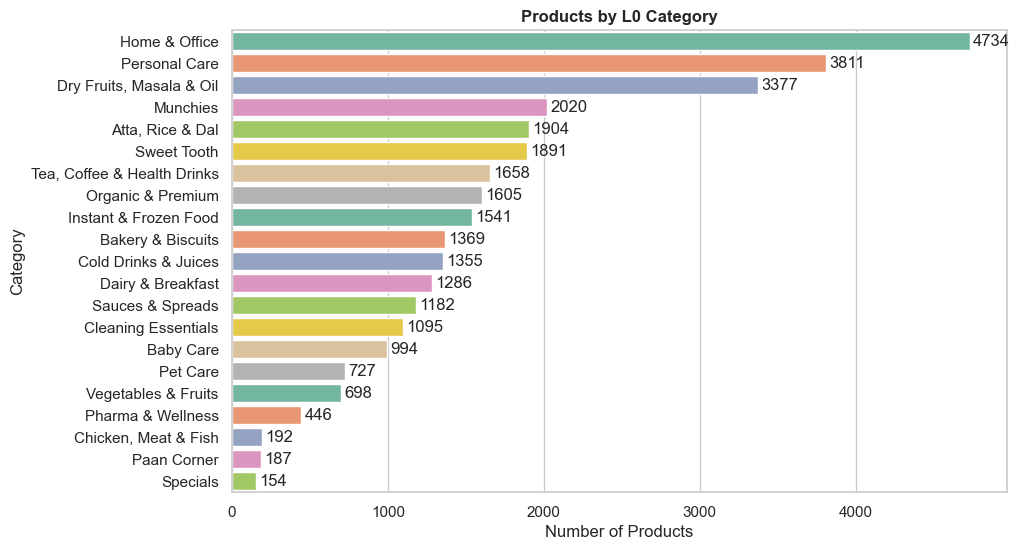

In [ ]:
l0_counts = products['l0_category'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=l0_counts.values,
                 y=l0_counts.index,
                 palette='Set2')

for i, v in enumerate(l0_counts.values):
    ax.text(v + 20, i, str(v), va='center')

plt.title('Products by L0 Category', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

### Key Insights

- Home & Office is the largest category with 4,734 products, making it the most diverse segment in the catalog.
- Personal Care and Dry Fruits, Masala & Oil are the next most represented categories, indicating strong product depth in essential FMCG segments.
- The top few categories account for a significant share of the overall product assortment.
- Categories such as Specials, Paan Corner, and Chicken, Meat & Fish contain comparatively fewer products and represent niche segments within the catalog.

---
## Q2. Which Brands Have the Widest Category Presence?

A brand appearing across multiple categories indicates a diversified portfolio  
and higher cross-sell potential on the platform.

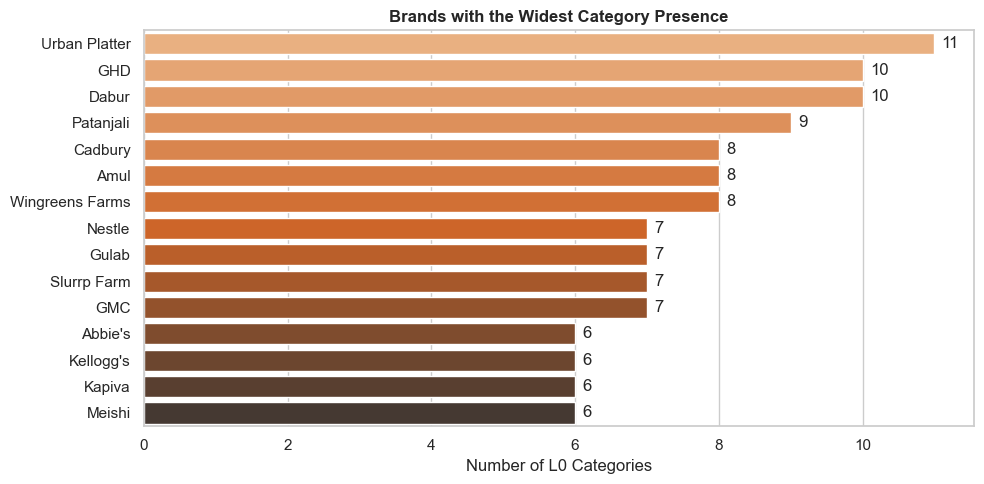

In [ ]:
brand_reach = (
    products.groupby('brand_name')['l0_category']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=brand_reach.values,
    y=brand_reach.index,
    palette='Oranges_d'
)

for i, v in enumerate(brand_reach.values):
    ax.text(v + 0.1, i, str(v), va='center')

plt.title('Brands with the Widest Category Presence', fontweight='bold')
plt.xlabel('Number of L0 Categories')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Key Insights

- Urban Platter has the widest category presence, operating across 11 L0 categories.
- Dabur and GHD also maintain highly diversified portfolios across multiple product segments.
- Several leading brands operate across 8–10 categories, indicating broad market coverage.
- Wider category presence suggests stronger diversification and greater cross-selling opportunities.

---
## Q3. Which Manufacturers Dominate the Catalog?

Manufacturer concentration reveals supply chain dependencies —  
if one manufacturer dominates, the platform is exposed to supply risk.

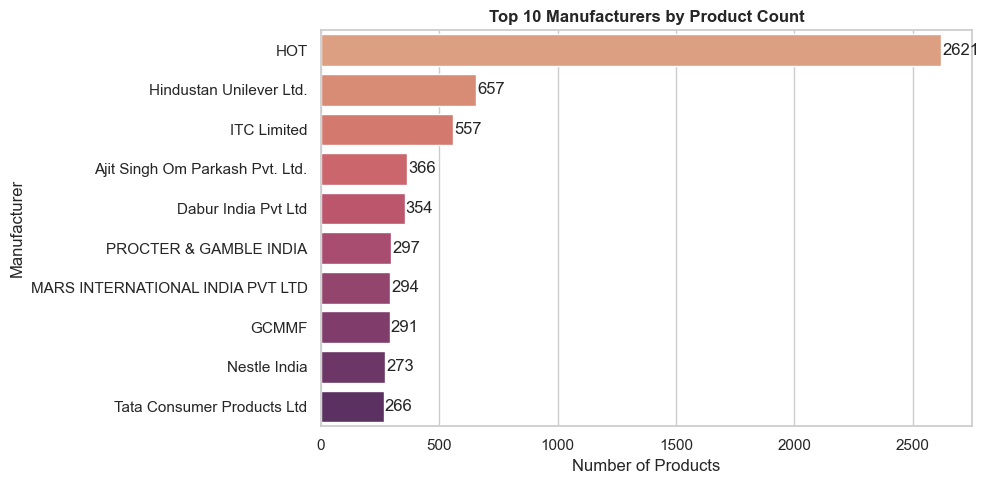

In [ ]:
top_manufacturers = products['manufacturer_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=top_manufacturers.values,
    y=top_manufacturers.index,
    palette='flare'
)

for i, v in enumerate(top_manufacturers.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title('Top 10 Manufacturers by Product Count', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Manufacturer')

plt.tight_layout()
plt.show()

### Key Insights

- HOT is the largest manufacturer in the catalog with 2,621 products, significantly ahead of all other manufacturers.
- Hindustan Unilever Ltd. and ITC Limited are the leading national FMCG manufacturers by product count.
- The product catalog is concentrated among a few major manufacturers, indicating their strong presence across categories.
- A diverse manufacturer base still exists beyond the top contributors, reducing dependence on a single supplier.

---
## Q4. Which L1 Categories Have the Highest Product Concentration?
Analyzing mid-level categories helps identify where product assortment is most concentrated within the catalog.

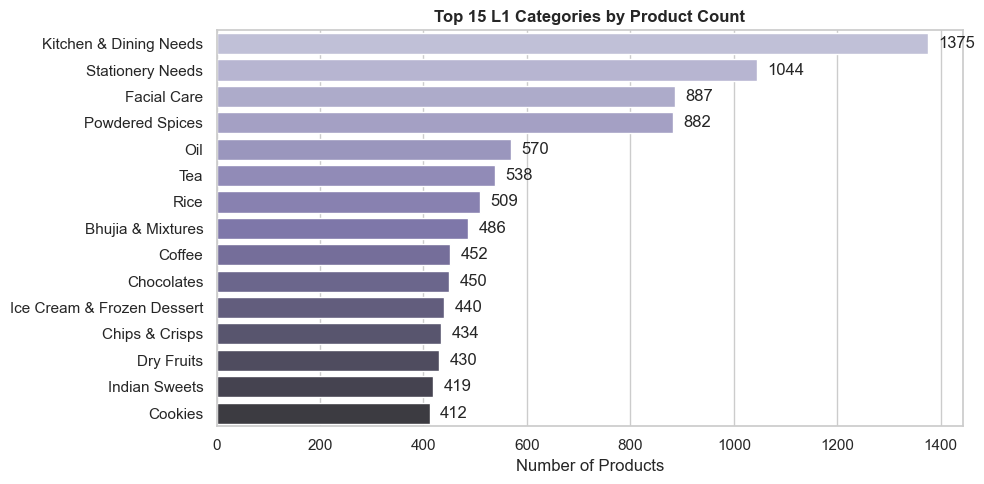

In [ ]:
top_l1 = products['l1_category'].value_counts().head(15)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=top_l1.values,
    y=top_l1.index,
    palette='Purples_d'
)

for i, v in enumerate(top_l1.values):
    ax.text(v + 20, i, str(v), va='center')

plt.title('Top 15 L1 Categories by Product Count', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Key Insights

- Kitchen & Dining Needs is the largest L1 category by product count.
- Stationery Needs, Facial Care, and Powdered Spices also contain a substantial number of products.
- Product concentration is distributed across multiple L1 categories rather than being dominated by a single segment.
- High-product categories represent key areas where customers have the widest range of choices.

---
# Final Conclusion

The product catalog contains 32,226 unique products organized across multiple category levels, brands, and manufacturers.

The analysis revealed that Home & Office, Personal Care, and Dry Fruits, Masala & Oil are the largest product categories. A few leading brands and manufacturers contribute a significant share of the catalog, while category coverage varies across brands.

Overall, the catalog is well-diversified, with strong representation across major FMCG segments and a structured category hierarchy that supports product discovery and assortment management.

---
# Business Recommendations

### 1. Expand High-Growth Categories

Focus on strengthening high-variety categories such as Home & Office and Personal Care, as they already demonstrate strong catalog depth and customer choice.

### 2. Improve Underrepresented Categories

Categories such as Specials, Paan Corner, and Chicken, Meat & Fish contain relatively fewer products and may benefit from catalog expansion to improve assortment coverage.

### 3. Strengthen Strategic Brand Partnerships

Brands with broad category presence, such as Urban Platter, Dabur, and GHD, should be prioritized for partnership programs, promotions, and cross-category campaigns.

### 4. Reduce Supplier Concentration Risk

A significant share of products originates from a small group of manufacturers. Expanding the supplier base can improve catalog resilience and reduce dependency on a few key manufacturers.

### 5. Optimize Category Navigation

Highly populated L1 categories should be supported with effective filtering, search, and recommendation systems to improve product discoverability and customer experience.